# 020 - Gerar relatório de dados por UF

Este notebook consome os CSVs produzidos pelo notebook `010_extracao_transformacao.ipynb` e gera os insumos do relatório estadual: tabelas, gráficos PNG e documento Word.

Fluxo de trabalho:
1. ler bases consolidadas em CSV;
2. filtrar uma Unidade da Federacao;
3. tratar cada política em uma seção própria;
4. imprimir e salvar as tabelas;
5. gerar, imprimir e salvar os gráficos PNG;
6. montar o documento Word apenas depois que todos os insumos estiverem prontos.

O documento Word nao possui capa. Ele comeca com titulo, sumário executivo, secoes por política e fontes.

## 1. Importar bibliotecas

As bibliotecas abaixo cobrem leitura dos CSVs, geracao dos graficos, criacao do Word e organizacao de caminhos.

In [1]:
from datetime import datetime
from pathlib import Path
import os

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    from docx import Document
    from docx.shared import Inches, Pt, RGBColor
    from docx.enum.text import WD_ALIGN_PARAGRAPH
    from docx.enum.table import WD_CELL_VERTICAL_ALIGNMENT
    from docx.oxml import OxmlElement
    from docx.oxml.ns import qn
except ImportError:
    # Mantem o notebook executavel em ambientes novos, como Colab recem-iniciado.
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "python-docx"])
    from docx import Document
    from docx.shared import Inches, Pt, RGBColor
    from docx.enum.text import WD_ALIGN_PARAGRAPH
    from docx.enum.table import WD_CELL_VERTICAL_ALIGNMENT
    from docx.oxml import OxmlElement
    from docx.oxml.ns import qn

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

# Estilo visual simples e consistente para todos os graficos.
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 2. Configurar parametros

Altere `UF_INTERESSE` para gerar o relatorio de outra UF. O notebook procura automaticamente a pasta mais recente dentro de `dados_intermediarios` quando `ANO_MES_INTERMEDIARIO` fica como `None`.

In [2]:
# O notebook continua linear e gera um relat?rio por execu??o.
# Para execu??o em lote, o notebook 030 passa estes par?metros por vari?vel de ambiente.
UF_INTERESSE = os.environ.get("UF_INTERESSE", "SC").strip().upper()
ANO_MES_INTERMEDIARIO = os.environ.get("ANO_MES_INTERMEDIARIO") or None
TEXTO_RODAPE = "Contribuições e Dúvidas: damei@mda.gov.br"
PLACEHOLDER_TOTAL_PAGINAS = "[[TOTAL_PAGINAS]]"
ARQUIVO_IMAGEM_CABECALHO = "cabecalho_mda_brasil.png"
LARGURA_IMAGEM_CABECALHO_POLEGADAS = 2.55

RUN_TIMESTAMP = datetime.now()
RUN_YYYYMM = RUN_TIMESTAMP.strftime("%Y%m")
RUN_DATETIME = RUN_TIMESTAMP.strftime("%Y%m%d%H%M%S")

CSV_SEP = ";"
CSV_ENCODING = "utf-8-sig"

MODO_DADOS = "google_drive" if "COLAB_RELEASE_TAG" in os.environ else "local"
print(f"Modo de execucao: {MODO_DADOS}")
print(f"UF de interesse: {UF_INTERESSE}")

Modo de execucao: local
UF de interesse: BA


## 3. Resolver caminhos

A estrutura de saida separa tabelas e graficos por UF. Isso evita sobrescrever arquivos quando diferentes estados forem gerados em sequencia.

Estrutura principal usada pelo notebook:

```text
relatorios_gerados/
  <AAAAMM>/
    tabelas/<UF>/
    graficos/<UF>/
    relatorio_dados_<UF>_<timestamp>.docx
```

In [3]:
inicio = Path.cwd().resolve()
PROJECT_ROOT = inicio

# Procura a raiz do repositorio a partir da pasta atual.
for candidato in [inicio, *inicio.parents]:
    if (candidato / "notebooks").exists() and ((candidato / "requirements.txt").exists() or (candidato / "config" / "ufs.csv").exists()):
        PROJECT_ROOT = candidato
        break

if MODO_DADOS == "google_drive":
    from google.colab import drive
    drive.mount("/content/drive")

INTERMEDIARIOS_ROOT = PROJECT_ROOT / "dados_intermediarios"
if ANO_MES_INTERMEDIARIO is None:
    candidatos = sorted([p for p in INTERMEDIARIOS_ROOT.iterdir() if p.is_dir()]) if INTERMEDIARIOS_ROOT.exists() else []
    if not candidatos:
        raise FileNotFoundError(f"Nenhuma pasta encontrada em {INTERMEDIARIOS_ROOT}. Execute primeiro o notebook 010.")
    INPUT_DIR = candidatos[-1]
else:
    INPUT_DIR = INTERMEDIARIOS_ROOT / ANO_MES_INTERMEDIARIO

CONSOLIDADO_DIR = INPUT_DIR / "consolidado"
OUTPUT_DIR = PROJECT_ROOT / "relatorios_gerados" / INPUT_DIR.name
TABELAS_DIR = OUTPUT_DIR / "tabelas" / UF_INTERESSE.upper()
GRAFICOS_DIR = OUTPUT_DIR / "graficos" / UF_INTERESSE.upper()
IMAGENS_TEMPLATE_DIR = PROJECT_ROOT / "templates" / "imagens"
IMAGENS_INSTITUCIONAIS_DIR = IMAGENS_TEMPLATE_DIR / "institucional"
IMAGENS_POLITICAS_DIR = IMAGENS_TEMPLATE_DIR / "politicas"
CAMINHO_IMAGEM_CABECALHO = IMAGENS_INSTITUCIONAIS_DIR / ARQUIVO_IMAGEM_CABECALHO

# A pasta de imagens guarda ativos reutilizaveis do relatorio.
# - institucional: assinatura do cabecalho e marcas gerais do documento.
# - politicas: logos futuras de CAF, PRONAF, ATER, Mais Alimentos e outras politicas.
for pasta in [OUTPUT_DIR, TABELAS_DIR, GRAFICOS_DIR, IMAGENS_TEMPLATE_DIR, IMAGENS_INSTITUCIONAIS_DIR, IMAGENS_POLITICAS_DIR]:
    pasta.mkdir(parents=True, exist_ok=True)

print(f"Raiz do projeto: {PROJECT_ROOT}")
print(f"Entrada intermediaria: {INPUT_DIR}")
print(f"Tabelas: {TABELAS_DIR}")
print(f"Graficos: {GRAFICOS_DIR}")

Raiz do projeto: C:\Users\marce\OneDrive - Ministério da Agricultura e Pecuária\LAB_DATA_MDA\20260424_relatorio_dados\relatorio_dados_damei
Entrada intermediaria: C:\Users\marce\OneDrive - Ministério da Agricultura e Pecuária\LAB_DATA_MDA\20260424_relatorio_dados\relatorio_dados_damei\dados_intermediarios\202605
Tabelas: C:\Users\marce\OneDrive - Ministério da Agricultura e Pecuária\LAB_DATA_MDA\20260424_relatorio_dados\relatorio_dados_damei\relatorios_gerados\202605\tabelas\BA
Graficos: C:\Users\marce\OneDrive - Ministério da Agricultura e Pecuária\LAB_DATA_MDA\20260424_relatorio_dados\relatorio_dados_damei\relatorios_gerados\202605\graficos\BA


## 4. Ler bases consolidadas

O relatorio usa apenas os CSVs consolidados da ETL. Ele nao volta aos arquivos Excel brutos.

In [4]:
indicadores_path = CONSOLIDADO_DIR / "indicadores_brasil_uf.csv"
series_path = CONSOLIDADO_DIR / "series_historicas_pronaf_ater_uf.csv"

if not indicadores_path.exists():
    raise FileNotFoundError(f"Arquivo nao encontrado: {indicadores_path}")
if not series_path.exists():
    raise FileNotFoundError(f"Arquivo nao encontrado: {series_path}")

df_indicadores = pd.read_csv(indicadores_path, sep=CSV_SEP, encoding=CSV_ENCODING)
df_series = pd.read_csv(series_path, sep=CSV_SEP, encoding=CSV_ENCODING)

# Padroniza campos textuais usados nos filtros.
df_indicadores["uf"] = df_indicadores["uf"].astype(str).str.strip().str.upper()
df_indicadores["politica"] = df_indicadores["politica"].astype(str).str.strip()
df_indicadores["indicador"] = df_indicadores["indicador"].astype(str).str.strip()
df_series["uf"] = df_series["uf"].astype(str).str.strip().str.upper()
df_series["politica"] = df_series["politica"].astype(str).str.strip()
df_series["indicador"] = df_series["indicador"].astype(str).str.strip()
df_series["ano"] = pd.to_numeric(df_series["ano"], errors="coerce").astype("Int64")

if "ranking_brasil" not in df_indicadores.columns:
    raise ValueError("A coluna ranking_brasil nao foi encontrada em indicadores_brasil_uf.csv. Execute primeiro o notebook 010_extracao_transformacao.ipynb atualizado.")

df_indicadores["valor_uf"] = pd.to_numeric(df_indicadores["valor_uf"], errors="coerce")
df_indicadores["valor_brasil"] = pd.to_numeric(df_indicadores["valor_brasil"], errors="coerce").fillna(0)
df_indicadores["percentual_uf_brasil"] = pd.to_numeric(df_indicadores["percentual_uf_brasil"], errors="coerce")
df_indicadores["ranking_brasil"] = df_indicadores["ranking_brasil"].fillna("Sem Informação").astype(str).str.strip()
df_series["valor"] = pd.to_numeric(df_series["valor"], errors="coerce").fillna(0)

display(df_indicadores.head())
display(df_series.head())

,politica,indicador,uf,codigo_ibge,nome_uf,valor_uf,valor_brasil,percentual_uf_brasil,ranking_brasil,formato,dt_referencia,dt_geracao,arquivo_origem
0,CAF,UFPA,AC,12,Acre,33319.0,3898268.0,0.854713,22,inteiro,2026_03,2026_04_10,caf_dap_ativos_ate_2026_03_gerado_em_202604101...
1,CAF,UFPA,AL,27,Alagoas,91048.0,3898268.0,2.335601,12,inteiro,2026_03,2026_04_10,caf_dap_ativos_ate_2026_03_gerado_em_202604101...
2,CAF,UFPA,AP,16,Amapá,21471.0,3898268.0,0.550783,24,inteiro,2026_03,2026_04_10,caf_dap_ativos_ate_2026_03_gerado_em_202604101...
3,CAF,UFPA,AM,13,Amazonas,65014.0,3898268.0,1.667766,15,inteiro,2026_03,2026_04_10,caf_dap_ativos_ate_2026_03_gerado_em_202604101...
4,CAF,UFPA,BA,29,Bahia,720630.0,3898268.0,18.485902,1,inteiro,2026_03,2026_04_10,caf_dap_ativos_ate_2026_03_gerado_em_202604101...


,politica,ano,uf,codigo_ibge,nome_uf,indicador,valor,formato,dt_referencia,dt_geracao,arquivo_origem
0,PRONAF,2015,AC,12,Acre,Contratos,5.501000e+03,inteiro,2015_12,2026_04_29,pronaf_gaia_historico_anual_2015.xlsx
1,PRONAF,2015,AC,12,Acre,Valor total dos contratos,1.110044e+08,moeda,2015_12,2026_04_29,pronaf_gaia_historico_anual_2015.xlsx
2,PRONAF,2015,AC,12,Acre,Operacoes,5.501000e+03,inteiro,2015_12,2026_04_29,pronaf_gaia_historico_anual_2015.xlsx
3,PRONAF,2015,AL,27,Alagoas,Contratos,5.034000e+04,inteiro,2015_12,2026_04_29,pronaf_gaia_historico_anual_2015.xlsx
4,PRONAF,2015,AL,27,Alagoas,Valor total dos contratos,1.977084e+08,moeda,2015_12,2026_04_29,pronaf_gaia_historico_anual_2015.xlsx


## 5. Filtrar UF e preparar dados auxiliares

A base de indicadores ja traz `valor_brasil`, mas a base historica e agregada novamente para gerar as linhas do Brasil por ano.

In [5]:
UF_INTERESSE = UF_INTERESSE.strip().upper()

if UF_INTERESSE not in set(df_indicadores["uf"]):
    raise ValueError(f"UF {UF_INTERESSE} nao encontrada em indicadores_brasil_uf.csv")

nome_uf = df_indicadores.loc[df_indicadores["uf"] == UF_INTERESSE, "nome_uf"].dropna().iloc[0]
df_indicadores_uf = df_indicadores[df_indicadores["uf"] == UF_INTERESSE].copy()
df_series_uf = df_series[df_series["uf"] == UF_INTERESSE].copy()

# Brasil historico: soma dos valores das 27 UFs para cada politica, ano e indicador.
df_series_brasil = (
    df_series
    .groupby(["politica", "ano", "indicador", "formato"], as_index=False)
    .agg(valor_brasil=("valor", "sum"))
)

print(f"UF selecionada: {UF_INTERESSE} - {nome_uf}")
print(f"Indicadores da UF: {df_indicadores_uf.shape[0]}")
print(f"Linhas historicas da UF: {df_series_uf.shape[0]}")

UF selecionada: BA - Bahia
Indicadores da UF: 23
Linhas historicas da UF: 51


## 6. Sum\u00e1rio Executivo

Esta se\u00e7\u00e3o cria duas tabelas:

1. indicadores atuais principais por pol\u00edtica, comparando UF, Brasil e ranking da UF no m\u00eas de refer\u00eancia;
2. dados hist\u00f3ricos, quando dispon\u00edveis, somando os per\u00edodos `2019 a 2022` e `2023 a 2026`.

As duas tabelas s\u00e3o impressas no notebook e salvas em CSV para posterior inclus\u00e3o no Word.

In [6]:
# Tabela 1: indicadores atuais principais para leitura rapida da alta gestao.
indicadores_chave = [
    ("CAF", "UFPA"),
    ("PRONAF", "Valor total dos contratos"),
    ("Mais Alimentos", "Valor total dos contratos"),
    ("ATER", "Familias com ATER recebida no ano"),
    ("Garantia-Safra", "Agricultores com pagamento liberado"),
    ("PNCF", "Valor liberado"),
    ("PNRA", "Total de familias"),
]

linhas_sumario = []
for politica, indicador in indicadores_chave:
    linha = df_indicadores_uf[(df_indicadores_uf["politica"] == politica) & (df_indicadores_uf["indicador"] == indicador)]
    if linha.empty:
        continue
    row = linha.iloc[0]
    linhas_sumario.append({
        "politica": politica,
        "indicador": indicador,
        "valor_uf": row["valor_uf"],
        "valor_brasil": row["valor_brasil"],
        "percentual_uf_brasil": row["percentual_uf_brasil"],
        "ranking_brasil": row["ranking_brasil"],
        "formato": row["formato"],
    })

df_sumario_executivo = pd.DataFrame(linhas_sumario)
df_sumario_executivo.to_csv(TABELAS_DIR / "sumario_executivo_indicadores_atuais.csv", sep=CSV_SEP, index=False, encoding=CSV_ENCODING)
display(df_sumario_executivo)

# Tabela 2: comparacao historica de periodos. Usa apenas as politicas com serie historica disponivel.
# O periodo 2023-2026 soma os anos disponiveis dentro desse intervalo; se 2026 ainda nao existir para uma serie, ele nao e inventado.
indicadores_historicos_chave = [
    ("PRONAF", "Valor total dos contratos"),
    ("PRONAF", "Contratos"),
    ("PRONAF", "Operacoes"),
    ("ATER", "Familias com ATER recebida no ano"),
    ("ATER", "Familias com ATER iniciada no ano"),
]

linhas_historico = []
for politica, indicador in indicadores_historicos_chave:
    serie_uf = df_series_uf[(df_series_uf["politica"] == politica) & (df_series_uf["indicador"] == indicador)].copy()
    serie_br = df_series_brasil[(df_series_brasil["politica"] == politica) & (df_series_brasil["indicador"] == indicador)].copy()
    if serie_uf.empty or serie_br.empty:
        continue

    formato = serie_uf["formato"].dropna().iloc[0] if not serie_uf["formato"].dropna().empty else "inteiro"

    uf_2019_2022 = serie_uf[serie_uf["ano"].between(2019, 2022, inclusive="both")]["valor"].sum()
    uf_2023_2026 = serie_uf[serie_uf["ano"].between(2023, 2026, inclusive="both")]["valor"].sum()
    br_2019_2022 = serie_br[serie_br["ano"].between(2019, 2022, inclusive="both")]["valor_brasil"].sum()
    br_2023_2026 = serie_br[serie_br["ano"].between(2023, 2026, inclusive="both")]["valor_brasil"].sum()

    anos_uf_2019_2022 = ", ".join(str(int(a)) for a in sorted(serie_uf[serie_uf["ano"].between(2019, 2022, inclusive="both")]["ano"].dropna().unique()))
    anos_uf_2023_2026 = ", ".join(str(int(a)) for a in sorted(serie_uf[serie_uf["ano"].between(2023, 2026, inclusive="both")]["ano"].dropna().unique()))

    variacao_uf = ((uf_2023_2026 / uf_2019_2022) - 1) * 100 if uf_2019_2022 else 0
    variacao_brasil = ((br_2023_2026 / br_2019_2022) - 1) * 100 if br_2019_2022 else 0

    linhas_historico.append({
        "politica": politica,
        "indicador": indicador,
        "uf": UF_INTERESSE,
        "valor_uf_2019_2022": uf_2019_2022,
        "valor_uf_2023_2026": uf_2023_2026,
        "variacao_uf_pct": variacao_uf,
        "valor_brasil_2019_2022": br_2019_2022,
        "valor_brasil_2023_2026": br_2023_2026,
        "variacao_brasil_pct": variacao_brasil,
        "anos_uf_2019_2022": anos_uf_2019_2022,
        "anos_uf_2023_2026": anos_uf_2023_2026,
        "formato": formato,
    })

df_sumario_historico = pd.DataFrame(linhas_historico)
df_sumario_historico.to_csv(TABELAS_DIR / "sumario_executivo_historico_2019_2022_2023_2026.csv", sep=CSV_SEP, index=False, encoding=CSV_ENCODING)
display(df_sumario_historico)

,politica,indicador,valor_uf,valor_brasil,percentual_uf_brasil,ranking_brasil,formato
0,CAF,UFPA,7.206300e+05,3.898268e+06,18.485902,1,inteiro
1,PRONAF,Valor total dos contratos,1.229654e+09,1.467108e+10,8.381480,5,moeda
2,Mais Alimentos,Valor total dos contratos,1.474165e+08,3.533334e+09,4.172164,6,moeda
3,ATER,Familias com ATER recebida no ano,6.460000e+02,1.685500e+04,3.832691,9,inteiro
4,Garantia-Safra,Agricultores com pagamento liberado,3.175220e+05,8.336210e+05,38.089492,1,inteiro
5,PNCF,Valor liberado,1.053556e+07,1.040243e+08,10.127979,4,moeda
6,PNRA,Total de familias,9.720000e+02,9.119000e+03,10.659063,3,inteiro


,politica,indicador,uf,valor_uf_2019_2022,valor_uf_2023_2026,variacao_uf_pct,valor_brasil_2019_2022,valor_brasil_2023_2026,variacao_brasil_pct,anos_uf_2019_2022,anos_uf_2023_2026,formato
0,PRONAF,Valor total dos contratos,BA,5.503546e+09,9.997415e+09,81.654067,1.471802e+11,1.860840e+11,26.432747,"2019, 2020, 2021, 2022","2023, 2024, 2025",moeda
1,PRONAF,Contratos,BA,8.459500e+05,8.131900e+05,-3.872569,5.690096e+06,5.455360e+06,-4.125343,"2019, 2020, 2021, 2022","2023, 2024, 2025",inteiro
2,PRONAF,Operacoes,BA,8.459500e+05,8.131900e+05,-3.872569,5.690096e+06,5.455360e+06,-4.125343,"2019, 2020, 2021, 2022","2023, 2024, 2025",inteiro
3,ATER,Familias com ATER recebida no ano,BA,8.639000e+03,8.290000e+03,-4.039819,2.098090e+05,9.244200e+04,-55.939926,"2019, 2020, 2021, 2022","2023, 2024, 2025, 2026",inteiro
4,ATER,Familias com ATER iniciada no ano,BA,2.646000e+03,3.458000e+03,30.687831,4.290000e+04,3.690400e+04,-13.976690,"2019, 2020, 2021, 2022","2023, 2024, 2025, 2026",inteiro


## 7. Funcoes auxiliares de apresentacao

As funcoes abaixo ficam concentradas aqui para evitar repeticao na montagem das tabelas, graficos e Word. A regra de negocio ja veio pronta da ETL; aqui o foco e apenas apresentacao.

In [7]:
def formatar_valor(valor, formato):
    """Formata valores numericos como inteiro ou moeda em padrao brasileiro."""
    if pd.isna(valor):
        return "Sem Informação"
    valor = float(valor)
    if formato == "moeda":
        return "R$ " + f"{valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return f"{valor:,.0f}".replace(",", ".")


def formatar_percentual(valor):
    """Formata percentual com duas casas decimais."""
    if pd.isna(valor):
        return "Sem Informação"
    valor = float(valor)
    return f"{valor:.2f}%".replace(".", ",")


def formatar_ranking(valor):
    """Formata a posicao da UF no ranking nacional do indicador."""
    if pd.isna(valor):
        return "Sem Informação"
    texto = str(valor).strip()
    if texto == "" or texto.lower() in ["nan", "<na>", "sem informação", "sem informacao"]:
        return "Sem Informação"
    texto = texto.replace(chr(186), "").strip()
    return f"{int(float(texto))}{chr(186)}"



def texto_ptbr(texto):
    """Padroniza textos de exibi??o em portugu?s do Brasil, preservando os dados originais."""
    if pd.isna(texto):
        return texto
    texto = str(texto)
    substituicoes = {
        "Relatorio": "Relat\u00f3rio", "relatorio": "relat\u00f3rio",
        "Sumario": "Sum\u00e1rio", "sumario": "sum\u00e1rio",
        "Participacao": "Participa\u00e7\u00e3o", "participacao": "participa\u00e7\u00e3o",
        "posicao": "posi\u00e7\u00e3o", "referencia": "refer\u00eancia",
        "politica": "pol\u00edtica", "politicas": "pol\u00edticas",
        "propria": "pr\u00f3pria", "historico": "hist\u00f3rico", "Historico": "Hist\u00f3rico",
        "disponiveis": "dispon\u00edveis", "periodos": "per\u00edodos", "periodo": "per\u00edodo",
        "execucao": "execu\u00e7\u00e3o", "pagina": "p\u00e1gina", "Pagina": "P\u00e1gina",
        "rodape": "rodap\u00e9", "cabecalho": "cabe\u00e7alho", "Agraria": "Agr\u00e1ria",
        "exibicao": "exibi\u00e7\u00e3o", "informacao": "informa\u00e7\u00e3o",
        "geracao": "gera\u00e7\u00e3o", "Geracao": "Gera\u00e7\u00e3o", "mes": "m\u00eas", "ate": "at\u00e9",
        "Familias": "Fam\u00edlias", "familias": "fam\u00edlias",
        "Operacoes": "Opera\u00e7\u00f5es", "operacoes": "opera\u00e7\u00f5es", "operacao": "opera\u00e7\u00e3o",
        "Juridica": "Jur\u00eddica", "Fisica": "F\u00edsica", "medio": "m\u00e9dio",
        "regularizacao": "regulariza\u00e7\u00e3o",
    }
    for origem, destino in substituicoes.items():
        texto = texto.replace(origem, destino)
    return texto


def titulo_grafico_word(caminho_grafico, numero_grafico):
    """Cria legenda numerada e institucional para os gráficos inseridos no Word."""
    mapa = {
        "caf_participacao": f"Participação de {nome_uf} nos indicadores do CAF em relação ao Brasil",
        "pronaf_valor_historico": "Histórico do valor total dos contratos do PRONAF",
        "pronaf_contratos_historico": "Histórico do número de contratos do PRONAF",
        "pronaf_participacao": f"Participação de {nome_uf} nos indicadores do PRONAF em relação ao Brasil",
        "mais_alimentos_participacao": f"Participação de {nome_uf} nos indicadores do Mais Alimentos em relação ao Brasil",
        "ater_recebida_historico": "Histórico de famílias com ATER recebida",
        "ater_iniciada_historico": "Histórico de famílias com ATER iniciada",
        "ater_participacao": f"Participação de {nome_uf} nos indicadores de ATER em relação ao Brasil",
        "garantia_safra_participacao": f"Participação de {nome_uf} nos indicadores do Garantia-Safra em relação ao Brasil",
        "pncf_participacao": f"Participação de {nome_uf} nos indicadores do PNCF em relação ao Brasil",
        "pnra_participacao": f"Participação de {nome_uf} nos indicadores do PNRA em relação ao Brasil",
    }
    stem = Path(caminho_grafico).stem
    titulo = mapa.get(stem, texto_ptbr(stem.replace("_", " ").title()))
    return f"Gráfico {numero_grafico} — {titulo}"

def preparar_tabela_exibicao(df):
    """Cria uma vers?o textual das tabelas para salvar e inserir no Word."""
    tabela = df.copy()
    if {"valor_uf", "valor_brasil", "percentual_uf_brasil", "formato"}.issubset(tabela.columns):
        rotulo_uf = UF_INTERESSE
        rotulo_percentual = f"% {UF_INTERESSE}/Brasil"
        tabela[rotulo_uf] = tabela.apply(lambda row: formatar_valor(row["valor_uf"], row["formato"]), axis=1)
        tabela["Brasil"] = tabela.apply(lambda row: formatar_valor(row["valor_brasil"], row["formato"]), axis=1)
        tabela[rotulo_percentual] = tabela["percentual_uf_brasil"].apply(formatar_percentual)
        colunas_exibicao = ["politica", "indicador", rotulo_uf, "Brasil", rotulo_percentual]
        if "ranking_brasil" in tabela.columns:
            tabela["Ranking Brasil"] = tabela["ranking_brasil"].apply(formatar_ranking)
            colunas_exibicao.append("Ranking Brasil")
        tabela = tabela[colunas_exibicao]
    return tabela


def salvar_tabela_politica(df, nome_arquivo):
    """Imprime a tabela no notebook e salva uma c?pia CSV na pasta da UF."""
    tabela = preparar_tabela_exibicao(df)
    tabela.to_csv(TABELAS_DIR / nome_arquivo, sep=CSV_SEP, index=False, encoding=CSV_ENCODING)
    display(tabela)
    return tabela


def grafico_participacao(df, titulo, arquivo_png):
    """Gera gr\u00e1fico de barras horizontais com participa\u00e7\u00e3o percentual UF/Brasil."""
    if df.empty:
        return None
    dados = df[df["percentual_uf_brasil"].notna()].sort_values("percentual_uf_brasil", ascending=True).copy()
    if dados.empty:
        print(f"Sem dados num\u00e9ricos para gerar o gr\u00e1fico: {texto_ptbr(titulo)}")
        return None
    dados["indicador_exibicao"] = dados["indicador"].apply(texto_ptbr)
    fig, ax = plt.subplots(figsize=(9, max(4, len(dados) * 0.5)))
    ax.barh(dados["indicador_exibicao"], dados["percentual_uf_brasil"], color="#1F77B4")
    ax.set_title(texto_ptbr(titulo))
    ax.set_xlabel(f"Participa\u00e7\u00e3o de {UF_INTERESSE} no Brasil (%)")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    for idx, valor in enumerate(dados["percentual_uf_brasil"]):
        ax.text(valor, idx, " " + formatar_percentual(valor), va="center", fontsize=9)
    fig.tight_layout()
    caminho = GRAFICOS_DIR / arquivo_png
    fig.savefig(caminho, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return caminho


def grafico_historico(politica, indicador, titulo, arquivo_png, formato="inteiro"):
    """Gera linha histórica comparando a UF selecionada com o Brasil."""
    serie_uf = df_series_uf[(df_series_uf["politica"] == politica) & (df_series_uf["indicador"] == indicador)].copy()
    serie_br = df_series_brasil[(df_series_brasil["politica"] == politica) & (df_series_brasil["indicador"] == indicador)].copy()
    if serie_uf.empty or serie_br.empty:
        print(f"Sem série histórica para {politica} - {indicador}")
        return None
    dados = serie_uf.merge(serie_br, on=["politica", "ano", "indicador", "formato"], how="inner")
    dados = dados.sort_values("ano")
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(dados["ano"].astype(int), dados["valor"], marker="o", label=UF_INTERESSE, color="#1F77B4")
    ax.plot(dados["ano"].astype(int), dados["valor_brasil"], marker="o", label="Brasil", color="#7F7F7F")
    ax.set_title(texto_ptbr(titulo))
    ax.set_xlabel("Ano")
    ax.legend()
    if formato == "moeda":
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"R$ {x/1e9:.1f} bi" if abs(x) >= 1e9 else f"R$ {x/1e6:.0f} mi"))
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))
    fig.tight_layout()
    caminho = GRAFICOS_DIR / arquivo_png
    fig.savefig(caminho, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return caminho




def aplicar_sombreamento_celula(celula, cor_hex):
    """Aplica cor de fundo em uma celula de tabela Word usando hexadecimal sem '#'."""
    tc_pr = celula._tc.get_or_add_tcPr()
    shading = OxmlElement("w:shd")
    shading.set(qn("w:fill"), cor_hex)
    tc_pr.append(shading)


def aplicar_bordas_celula(celula, cor_hex="D9E2F3", tamanho="4"):
    """Aplica bordas discretas em uma celula de tabela Word."""
    tc_pr = celula._tc.get_or_add_tcPr()
    bordas = tc_pr.first_child_found_in("w:tcBorders")
    if bordas is None:
        bordas = OxmlElement("w:tcBorders")
        tc_pr.append(bordas)
    for borda_nome in ["top", "left", "bottom", "right"]:
        borda = bordas.find(qn(f"w:{borda_nome}"))
        if borda is None:
            borda = OxmlElement(f"w:{borda_nome}")
            bordas.append(borda)
        borda.set(qn("w:val"), "single")
        borda.set(qn("w:sz"), tamanho)
        borda.set(qn("w:space"), "0")
        borda.set(qn("w:color"), cor_hex)


def definir_margens_celula(celula, margem_twips="70"):
    """Define margens internas para evitar texto colado nas bordas."""
    tc_pr = celula._tc.get_or_add_tcPr()
    margens = tc_pr.first_child_found_in("w:tcMar")
    if margens is None:
        margens = OxmlElement("w:tcMar")
        tc_pr.append(margens)
    for lado in ["top", "left", "bottom", "right"]:
        margem = margens.find(qn(f"w:{lado}"))
        if margem is None:
            margem = OxmlElement(f"w:{lado}")
            margens.append(margem)
        margem.set(qn("w:w"), margem_twips)
        margem.set(qn("w:type"), "dxa")



def definir_largura_celula(celula, largura_polegadas):
    """Define largura fixa da celula em polegadas para evitar tabela maior que a pagina."""
    largura_twips = str(int(largura_polegadas * 1440))
    celula.width = Inches(largura_polegadas)
    tc_pr = celula._tc.get_or_add_tcPr()
    largura = tc_pr.first_child_found_in("w:tcW")
    if largura is None:
        largura = OxmlElement("w:tcW")
        tc_pr.append(largura)
    largura.set(qn("w:w"), largura_twips)
    largura.set(qn("w:type"), "dxa")

def preparar_tabela_sumario_executivo_word(df):
    """Monta a tabela textual do Sumário Executivo com rótulos institucionais e UF dinamica."""
    tabela = preparar_tabela_exibicao(df).copy()
    mapa_colunas = {
        "politica": "Pol\u00edtica",
        "indicador": "Indicador",
        UF_INTERESSE: nome_uf,
        "Brasil": "Brasil",
        f"% {UF_INTERESSE}/Brasil": f"Participa\u00e7\u00e3o de {UF_INTERESSE} no Brasil",
        "Ranking Brasil": f"Posi\u00e7\u00e3o de {UF_INTERESSE} entre as UFs",
    }
    tabela = tabela.rename(columns=mapa_colunas)
    return tabela



def repetir_cabecalho_tabela(linha):
    """Marca a primeira linha da tabela para repetir como cabecalho quando houver quebra de pagina."""
    tr_pr = linha._tr.get_or_add_trPr()
    cabecalho = OxmlElement("w:tblHeader")
    cabecalho.set(qn("w:val"), "true")
    tr_pr.append(cabecalho)

def preparar_tabela_institucional_word(tabela):
    """Renomeia colunas recorrentes para exibi??o institucional no Word, sem alterar os dados de origem."""
    tabela_word = tabela.copy()
    for coluna_texto in ["politica", "indicador", "Pol?tica", "Indicador"]:
        if coluna_texto in tabela_word.columns:
            tabela_word[coluna_texto] = tabela_word[coluna_texto].apply(texto_ptbr)
    renomear = {
        "politica": "Pol\u00edtica",
        "indicador": "Indicador",
        UF_INTERESSE: nome_uf,
        f"% {UF_INTERESSE}/Brasil": f"Participa\u00e7\u00e3o de {UF_INTERESSE} no Brasil",
        "Ranking Brasil": f"Posi\u00e7\u00e3o de {UF_INTERESSE} entre as UFs",
        f"{UF_INTERESSE} 2019-2022": f"{UF_INTERESSE} 2019-2022",
        f"{UF_INTERESSE} 2023-2026": f"{UF_INTERESSE} 2023-2026",
        f"Var. {UF_INTERESSE}": f"Var. {UF_INTERESSE}",
        "dt_referencia": "M\u00eas de refer\u00eancia",
        "dt_geracao": "Data de gera\u00e7\u00e3o",
        "arquivo_origem": "Arquivo de origem",
    }
    tabela_word = tabela_word.rename(columns={col: renomear[col] for col in tabela_word.columns if col in renomear})
    for coluna_texto in ["Pol?tica", "Indicador"]:
        if coluna_texto in tabela_word.columns:
            tabela_word[coluna_texto] = tabela_word[coluna_texto].apply(texto_ptbr)
    return tabela_word


def preparar_tabela_sumario_executivo_word(df):
    """Monta a tabela textual do Sum\u00e1rio Executivo com r\u00f3tulos institucionais e UF dinamica."""
    tabela = preparar_tabela_exibicao(df).copy()
    return preparar_tabela_institucional_word(tabela)


def calcular_larguras_tabela_word(tabela):
    """Define larguras fixas dentro da area util da pagina, ajustadas pelo tipo de tabela."""
    colunas = list(tabela.columns)
    n_colunas = len(colunas)

    if n_colunas == 8:
        return [0.52, 0.92, 0.95, 0.95, 0.58, 1.12, 1.12, 0.58]
    if n_colunas == 6:
        if "Participa\u00e7\u00e3o" in " ".join(colunas) and "Posi\u00e7\u00e3o" in " ".join(colunas):
            return [0.68, 1.20, 1.50, 1.52, 1.10, 0.95]
        return [0.78, 1.55, 1.25, 1.25, 1.18, 0.84]
    if n_colunas == 5:
        return [0.85, 1.95, 1.30, 1.30, 1.20]
    if n_colunas == 4:
        return [0.85, 0.92, 0.92, 4.05]
    if n_colunas == 3:
        return [1.10, 1.55, 4.00]
    if n_colunas == 2:
        return [1.70, 5.00]

    largura_total = 6.85
    largura_padrao = max(0.55, largura_total / max(n_colunas, 1))
    return [largura_padrao] * n_colunas


def coluna_numerica_ou_ranking(nome_coluna):
    """Identifica colunas que devem ficar alinhadas a direita no Word."""
    texto = str(nome_coluna).lower()
    marcadores = [
        "brasil", "participa", "posi", "ranking", "var.", "2019", "2023",
        UF_INTERESSE.lower(), nome_uf.lower(), "valor", "total", "%",
    ]
    return any(marcador in texto for marcador in marcadores) and "indicador" not in texto and "pol" not in texto and "arquivo" not in texto


def adicionar_texto_apoio_tabela(doc, texto, negrito=False, italico=False, tamanho=8, espaco_depois=0):
    """Adiciona legenda, fonte ou nota de tabela com tipografia padronizada."""
    paragrafo = doc.add_paragraph(texto)
    paragrafo.paragraph_format.space_after = Pt(espaco_depois)
    for run in paragrafo.runs:
        run.font.name = "Arial"
        run.font.size = Pt(tamanho)
        run.bold = negrito
        run.italic = italico
    return paragrafo


def adicionar_tabela_formatada_word(doc, tabela, titulo_tabela, fonte=None, nota=None):
    """Insere tabela Word com o padr?o executivo usado no Sum?rio Executivo."""
    if tabela.empty:
        adicionar_texto_apoio_tabela(doc, titulo_tabela, negrito=True, tamanho=9, espaco_depois=2)
        doc.add_paragraph("Sem dados para exibi??o.")
        return

    fonte = fonte or "Fonte: elabora\u00e7\u00e3o pr\u00f3pria, com base nos dados administrativos das pol\u00edticas."
    nota = nota or "Nota: valores financeiros em reais correntes. Ranking calculado entre as Unidades da Federa\u00e7\u00e3o no m\u00eas de refer\u00eancia."

    adicionar_texto_apoio_tabela(doc, titulo_tabela, negrito=True, tamanho=9, espaco_depois=2)

    tabela_word = preparar_tabela_institucional_word(tabela)
    table = doc.add_table(rows=1, cols=len(tabela_word.columns))
    table.style = "Table Grid"
    table.autofit = False
    layout_fixo = OxmlElement("w:tblLayout")
    layout_fixo.set(qn("w:type"), "fixed")
    table._tbl.tblPr.append(layout_fixo)

    larguras = calcular_larguras_tabela_word(tabela_word)
    for idx, largura in enumerate(larguras[:len(tabela_word.columns)]):
        table.columns[idx].width = Inches(largura)

    cor_azul = "1F4E79"
    cor_cinza = "F4F6F8"
    cor_ranking = "EAF2F8"
    cor_borda = "D9E2F3"
    colunas_ranking = [col for col in tabela_word.columns if "Posi\u00e7\u00e3o" in str(col) or "Ranking" in str(col)]
    tamanho_fonte = 8 if len(tabela_word.columns) >= 8 else 9

    repetir_cabecalho_tabela(table.rows[0])

    for idx, coluna in enumerate(tabela_word.columns):
        cell = table.rows[0].cells[idx]
        definir_largura_celula(cell, larguras[idx])
        cell.text = str(coluna)
        cell.vertical_alignment = WD_CELL_VERTICAL_ALIGNMENT.CENTER
        aplicar_sombreamento_celula(cell, cor_azul)
        aplicar_bordas_celula(cell, cor_borda)
        definir_margens_celula(cell, "55" if len(tabela_word.columns) >= 8 else "70")
        for paragrafo in cell.paragraphs:
            paragrafo.alignment = WD_ALIGN_PARAGRAPH.LEFT
            for run in paragrafo.runs:
                run.bold = True
                run.font.name = "Arial"
                run.font.size = Pt(tamanho_fonte)
                run.font.color.rgb = RGBColor(255, 255, 255)

    for linha_idx, (_, row) in enumerate(tabela_word.iterrows(), start=1):
        cells = table.add_row().cells
        for col_idx, coluna in enumerate(tabela_word.columns):
            cell = cells[col_idx]
            definir_largura_celula(cell, larguras[col_idx])
            cell.text = str(row[coluna])
            cell.vertical_alignment = WD_CELL_VERTICAL_ALIGNMENT.CENTER
            aplicar_bordas_celula(cell, cor_borda)
            definir_margens_celula(cell, "55" if len(tabela_word.columns) >= 8 else "70")
            if coluna in colunas_ranking:
                aplicar_sombreamento_celula(cell, cor_ranking)
            elif linha_idx % 2 == 0:
                aplicar_sombreamento_celula(cell, cor_cinza)
            for paragrafo in cell.paragraphs:
                paragrafo.alignment = WD_ALIGN_PARAGRAPH.RIGHT if coluna_numerica_ou_ranking(coluna) else WD_ALIGN_PARAGRAPH.LEFT
                for run in paragrafo.runs:
                    run.font.name = "Arial"
                    run.font.size = Pt(tamanho_fonte)
                    if coluna in colunas_ranking:
                        run.bold = True
                        run.font.color.rgb = RGBColor(31, 78, 121)

    adicionar_texto_apoio_tabela(doc, fonte, italico=True, tamanho=8, espaco_depois=0)
    adicionar_texto_apoio_tabela(doc, nota, italico=True, tamanho=8, espaco_depois=10)


def adicionar_tabela_sumario_executivo_word(doc, tabela):
    """Mantem compatibilidade: insere a tabela 1 com o estilo institucional."""
    adicionar_tabela_formatada_word(
        doc,
        tabela,
        f"Tabela 1 \u2014 Indicadores selecionados de {nome_uf} em pol\u00edticas do MDA",
    )


def adicionar_dataframe_word(doc, tabela):
    """Insere um DataFrame pequeno como tabela no Word usando o padrao institucional."""
    adicionar_tabela_formatada_word(doc, tabela, "Tabela")


## 8. CAF - tabela e grafico

A tabela mostra os indicadores CAF da UF comparados ao Brasil. O grafico destaca a participacao percentual da UF no total nacional.

,politica,indicador,BA,Brasil,% BA/Brasil,Ranking Brasil
4,CAF,UFPA,720.630,3.898.268,"18,49%",1º
31,CAF,CAFs Pessoa Juridica ativos,2.064,9.161,"22,53%",1º
58,CAF,Mulheres em CAF ativo,655.056,3.529.596,"18,56%",1º
85,CAF,Homens em CAF ativo,626.049,3.519.584,"17,79%",1º


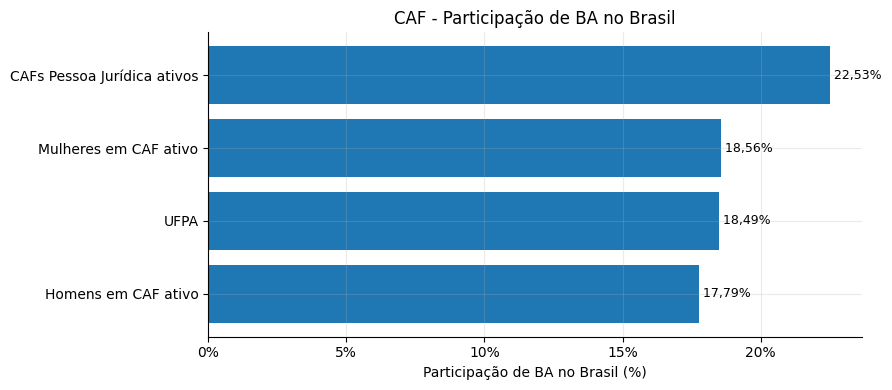

In [8]:
df_caf = df_indicadores_uf[df_indicadores_uf["politica"] == "CAF"].copy()
tabela_caf = salvar_tabela_politica(df_caf, "caf_tabela.csv")
grafico_caf = grafico_participacao(df_caf, f"CAF - Participa\u00e7\u00e3o de {UF_INTERESSE} no Brasil", "caf_participacao.png")

## 9. PRONAF - tabela e graficos

PRONAF possui dados atuais e serie historica. Por isso, sao gerados graficos de evolucao para valor total dos contratos e quantidade de contratos.

,politica,indicador,BA,Brasil,% BA/Brasil,Ranking Brasil
112,PRONAF,Contratos,84.248,482.017,"17,48%",1º
139,PRONAF,Valor total dos contratos,"R$ 1.229.653.837,93","R$ 14.671.081.816,64","8,38%",5º
166,PRONAF,Operacoes,84.248,482.017,"17,48%",1º
193,PRONAF,Contratos feminino,27.852,128.756,"21,63%",1º
220,PRONAF,Valor contratos feminino,"R$ 299.122.992,75","R$ 2.393.128.376,45","12,50%",1º


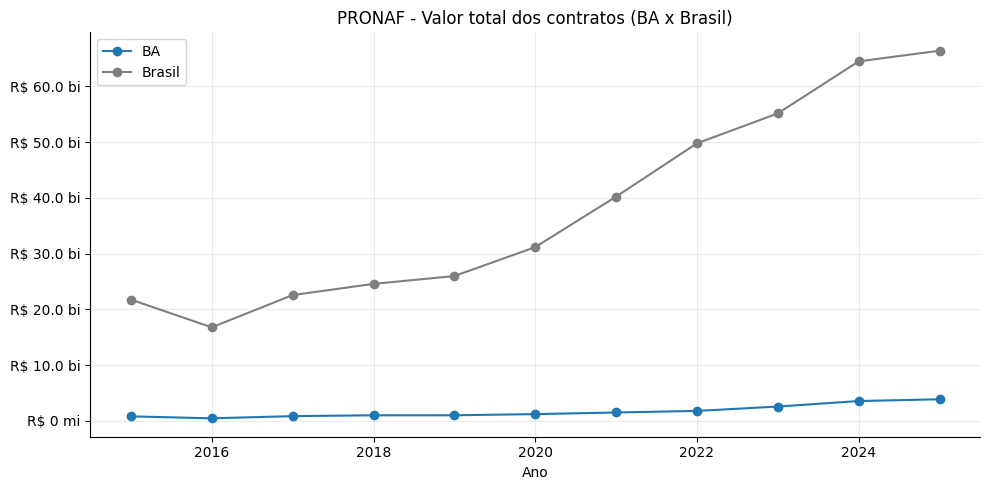

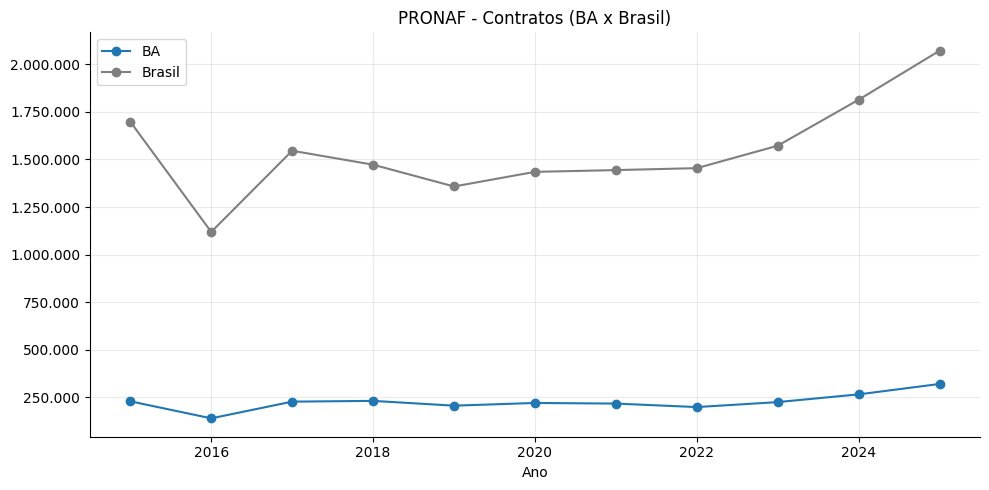

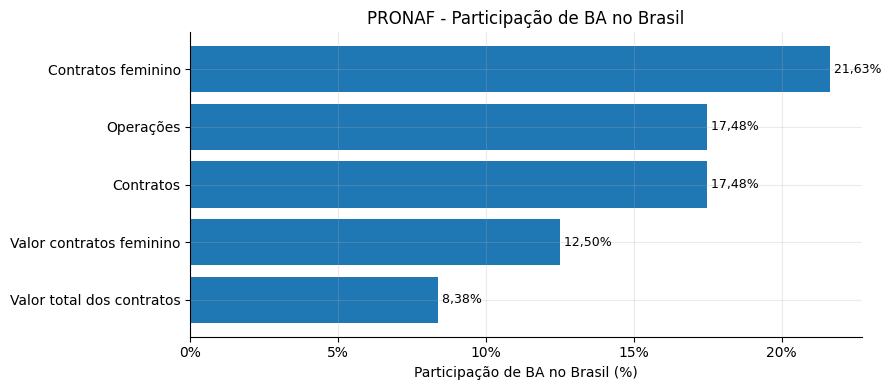

In [9]:
df_pronaf = df_indicadores_uf[df_indicadores_uf["politica"] == "PRONAF"].copy()
tabela_pronaf = salvar_tabela_politica(df_pronaf, "pronaf_tabela.csv")
grafico_pronaf_valor = grafico_historico("PRONAF", "Valor total dos contratos", f"PRONAF - Valor total dos contratos ({UF_INTERESSE} x Brasil)", "pronaf_valor_historico.png", formato="moeda")
grafico_pronaf_contratos = grafico_historico("PRONAF", "Contratos", f"PRONAF - Contratos ({UF_INTERESSE} x Brasil)", "pronaf_contratos_historico.png", formato="inteiro")
grafico_pronaf_participacao = grafico_participacao(df_pronaf, f"PRONAF - Participa\u00e7\u00e3o de {UF_INTERESSE} no Brasil", "pronaf_participacao.png")

## 10. Mais Alimentos - tabela e grafico

A base atual permite comparacao UF/Brasil para contratos e valor contratado.

,politica,indicador,BA,Brasil,% BA/Brasil,Ranking Brasil
247,Mais Alimentos,Contratos,13.068,95.355,"13,70%",1º
274,Mais Alimentos,Valor total dos contratos,"R$ 147.416.498,03","R$ 3.533.334.483,94","4,17%",6º


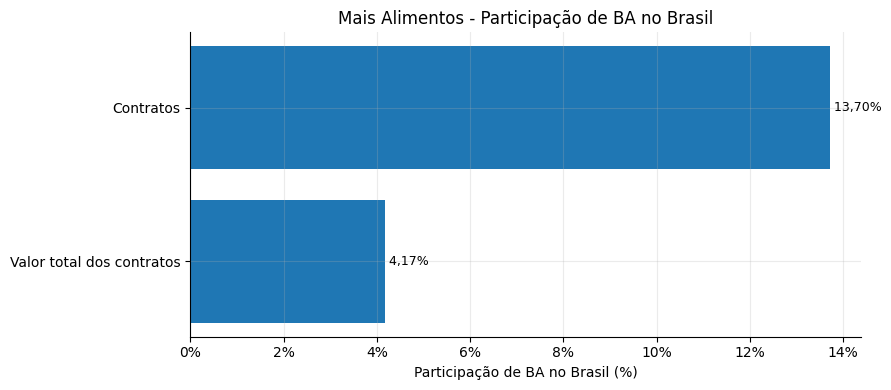

In [10]:
df_mais = df_indicadores_uf[df_indicadores_uf["politica"] == "Mais Alimentos"].copy()
tabela_mais = salvar_tabela_politica(df_mais, "mais_alimentos_tabela.csv")
grafico_mais = grafico_participacao(df_mais, f"Mais Alimentos - Participa\u00e7\u00e3o de {UF_INTERESSE} no Brasil", "mais_alimentos_participacao.png")

## 11. ATER - tabela e graficos

ATER possui dados atuais e serie historica. Sao gerados graficos para familias com ATER recebida e iniciada.

,politica,indicador,BA,Brasil,% BA/Brasil,Ranking Brasil
301,ATER,Familias com ATER iniciada no ano,141,5.785,"2,44%",15º
328,ATER,Familias com ATER recebida no ano,646,16.855,"3,83%",9º


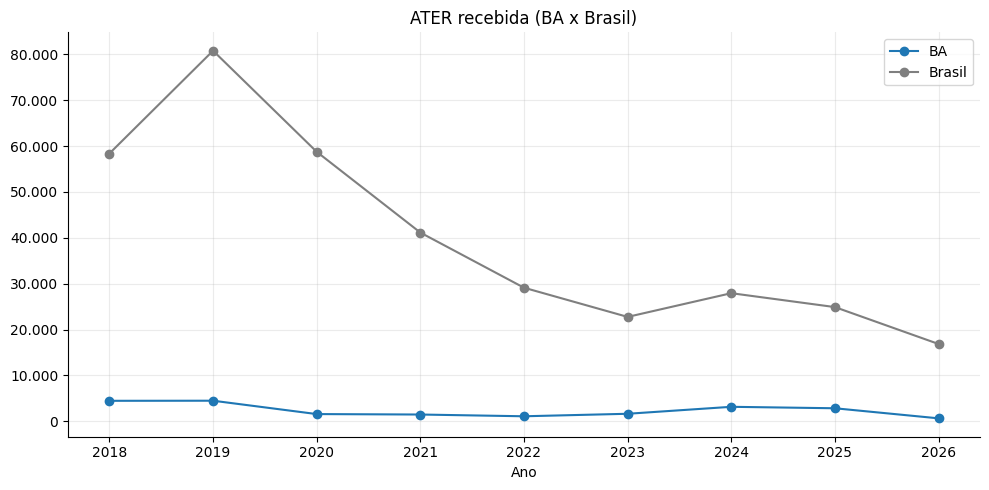

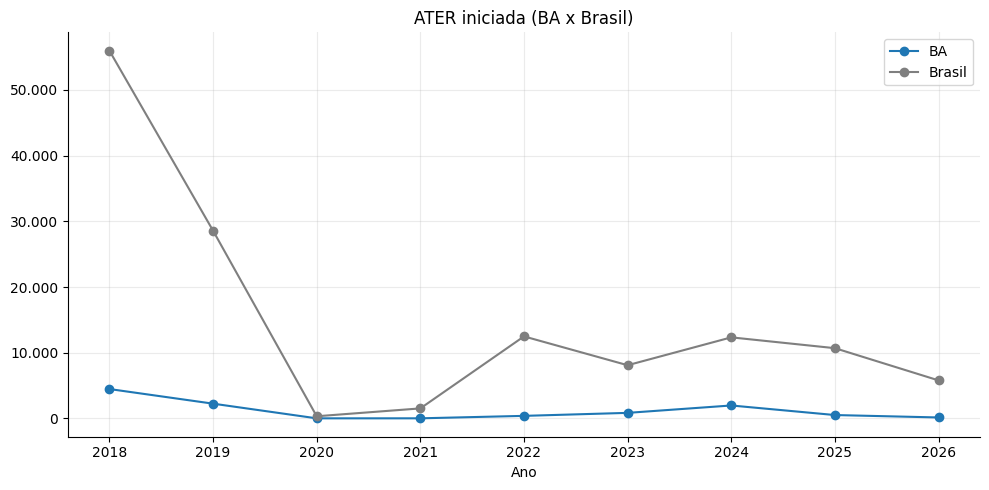

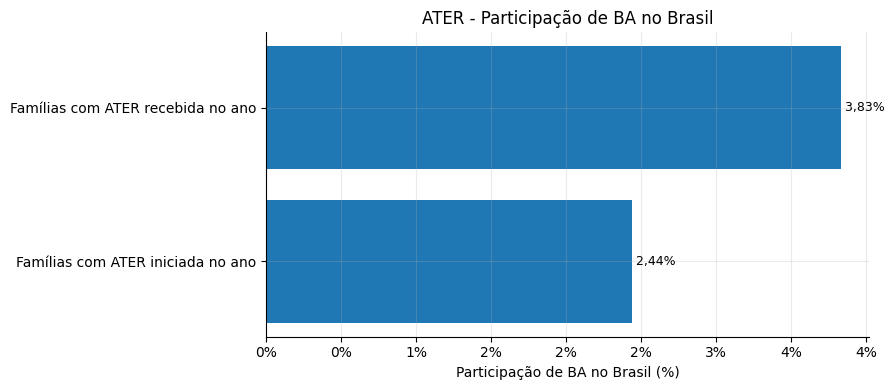

In [11]:
df_ater = df_indicadores_uf[df_indicadores_uf["politica"] == "ATER"].copy()
tabela_ater = salvar_tabela_politica(df_ater, "ater_tabela.csv")
grafico_ater_recebida = grafico_historico("ATER", "Familias com ATER recebida no ano", f"ATER recebida ({UF_INTERESSE} x Brasil)", "ater_recebida_historico.png", formato="inteiro")
grafico_ater_iniciada = grafico_historico("ATER", "Familias com ATER iniciada no ano", f"ATER iniciada ({UF_INTERESSE} x Brasil)", "ater_iniciada_historico.png", formato="inteiro")
grafico_ater_participacao = grafico_participacao(df_ater, f"ATER - Participa\u00e7\u00e3o de {UF_INTERESSE} no Brasil", "ater_participacao.png")

## 12. Garantia-Safra - tabela e grafico

A base atual permite comparar agricultores aderidos e agricultores com pagamento liberado.

,politica,indicador,BA,Brasil,% BA/Brasil,Ranking Brasil
355,Garantia-Safra,Agricultores aderidos,333.616,900.332,"37,05%",1º
382,Garantia-Safra,Agricultores com pagamento liberado,317.522,833.621,"38,09%",1º


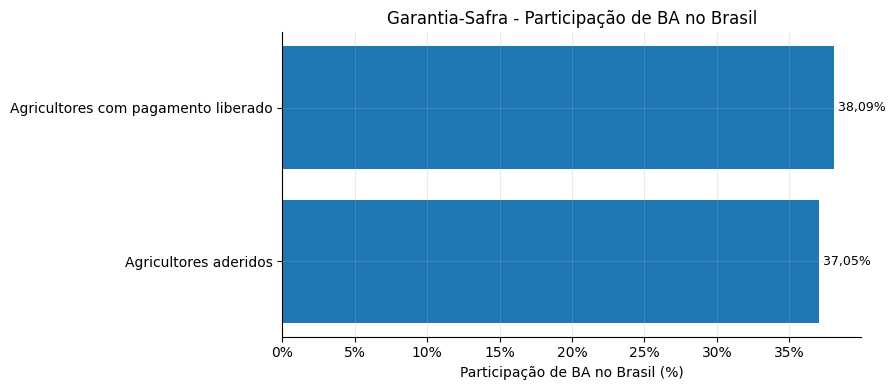

In [12]:
df_gs = df_indicadores_uf[df_indicadores_uf["politica"] == "Garantia-Safra"].copy()
tabela_gs = salvar_tabela_politica(df_gs, "garantia_safra_tabela.csv")
grafico_gs = grafico_participacao(df_gs, f"Garantia-Safra - Participa\u00e7\u00e3o de {UF_INTERESSE} no Brasil", "garantia_safra_participacao.png")

## 13. PNCF - tabela e grafico

PNCF traz operacoes, valor liberado e valor medio por operacao.

,politica,indicador,BA,Brasil,% BA/Brasil,Ranking Brasil
409,PNCF,Operacoes,40,417,"9,59%",5º
436,PNCF,Valor liberado,"R$ 10.535.558,58","R$ 104.024.293,61","10,13%",4º
463,PNCF,Valor medio liberado por operacao,"R$ 263.388,96","R$ 249.458,74","105,58%",9º


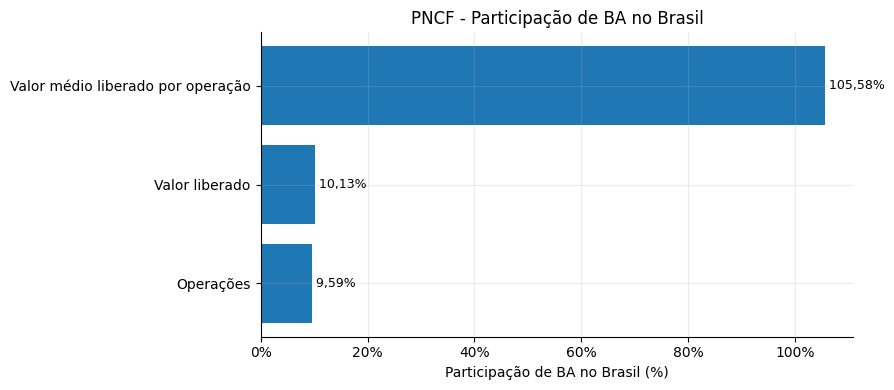

In [13]:
df_pncf = df_indicadores_uf[df_indicadores_uf["politica"] == "PNCF"].copy()
tabela_pncf = salvar_tabela_politica(df_pncf, "pncf_tabela.csv")
grafico_pncf = grafico_participacao(df_pncf, f"PNCF - Participa\u00e7\u00e3o de {UF_INTERESSE} no Brasil", "pncf_participacao.png")

## 14. PNRA - tabela e grafico

PNRA apresenta familias por categoria e total de familias.

,politica,indicador,BA,Brasil,% BA/Brasil,Ranking Brasil
490,PNRA,Familias em PA criado diferenciado,0,2.341,"0,00%",9º
517,PNRA,Familias em PA criado tradicional,0,40,"0,00%",4º
544,PNRA,Familias em reconhecimento,0,2.000,"0,00%",13º
571,PNRA,Familias em regularizacao,972,4.738,"20,51%",1º
598,PNRA,Total de familias,972,9.119,"10,66%",3º


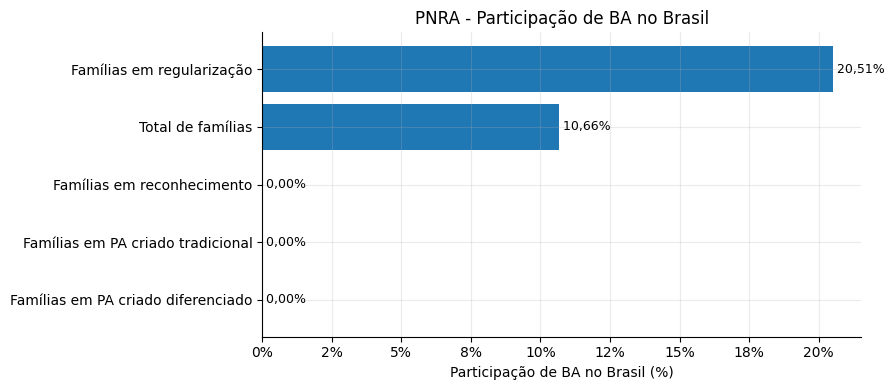

In [14]:
df_pnra = df_indicadores_uf[df_indicadores_uf["politica"] == "PNRA"].copy()
tabela_pnra = salvar_tabela_politica(df_pnra, "pnra_tabela.csv")
grafico_pnra = grafico_participacao(df_pnra, f"PNRA - Participa\u00e7\u00e3o de {UF_INTERESSE} no Brasil", "pnra_participacao.png")

## 15. Fontes

A tabela de fontes consolida política, data de referência, data de geração e arquivo de origem. Ela será inserida ao final do Word.

In [15]:
df_fontes = (
    df_indicadores_uf[["politica", "dt_referencia", "dt_geracao", "arquivo_origem"]]
    .drop_duplicates()
    .sort_values(["politica", "arquivo_origem"])
    .reset_index(drop=True)
)
df_fontes.to_csv(TABELAS_DIR / "fontes.csv", sep=CSV_SEP, index=False, encoding=CSV_ENCODING)
display(df_fontes)

,politica,dt_referencia,dt_geracao,arquivo_origem
0,ATER,2026_03,20260410,ater_ate_2026_03_gerado_em_20260410151127.xlsx
1,CAF,2026_03,2026_04_10,caf_dap_ativos_ate_2026_03_gerado_em_202604101...
2,Garantia-Safra,2023-2024,2026_04_13,GARANTIA-SAFRA_2023-2024_ate_2026_04.xlsx
3,Mais Alimentos,2026_03,2026_04_14,mais_alimentos_gaia_202604151554.xlsx
4,PNCF,2026_03,2026_04_10,pncf_2026_03_gerado_em_20260410170006.xlsx
5,PNRA,2026 até mar,2026_04_15,PNRA_2026_2026_04_15.xlsx
6,PRONAF,2026_03,2026_04_14,pronaf_gaia_20260414.xlsx


## 16. Conferir insumos gerados

Antes de montar o Word, o notebook lista tabelas e graficos salvos. Essa conferencia torna a montagem do documento mais previsivel.

In [16]:
tabelas_geradas = sorted(TABELAS_DIR.glob("*.csv"))
graficos_gerados = sorted(GRAFICOS_DIR.glob("*.png"))

df_insumos = pd.DataFrame(
    [{"tipo": "tabela", "arquivo": p.name, "caminho": str(p)} for p in tabelas_geradas]
    + [{"tipo": "grafico", "arquivo": p.name, "caminho": str(p)} for p in graficos_gerados]
)
display(df_insumos)

print(f"Tabelas geradas: {len(tabelas_geradas)}")
print(f"Graficos gerados: {len(graficos_gerados)}")

,tipo,arquivo,caminho
0,tabela,ater_tabela.csv,C:\Users\marce\OneDrive - Ministério da Agricu...
1,tabela,caf_tabela.csv,C:\Users\marce\OneDrive - Ministério da Agricu...
2,tabela,fontes.csv,C:\Users\marce\OneDrive - Ministério da Agricu...
3,tabela,garantia_safra_tabela.csv,C:\Users\marce\OneDrive - Ministério da Agricu...
4,tabela,mais_alimentos_tabela.csv,C:\Users\marce\OneDrive - Ministério da Agricu...
5,tabela,pncf_tabela.csv,C:\Users\marce\OneDrive - Ministério da Agricu...
6,tabela,pnra_tabela.csv,C:\Users\marce\OneDrive - Ministério da Agricu...
7,tabela,pronaf_tabela.csv,C:\Users\marce\OneDrive - Ministério da Agricu...
8,tabela,sumario_executivo_historico_2019_2022_2023_202...,C:\Users\marce\OneDrive - Ministério da Agricu...
9,tabela,sumario_executivo_indicadores_atuais.csv,C:\Users\marce\OneDrive - Ministério da Agricu...


Tabelas geradas: 10
Graficos gerados: 11


## 17. Montar documento Word

O Word e montado somente depois que as tabelas e os PNGs ja foram gerados. Isso separa a preparacao dos insumos da etapa editorial.

In [17]:
def adicionar_campo_word(paragrafo, instrucao, texto_padrao="1"):
    """Insere um campo dinamico do Word, como PAGE, em um paragrafo."""
    run_inicio = paragrafo.add_run()
    campo_inicio = OxmlElement("w:fldChar")
    campo_inicio.set(qn("w:fldCharType"), "begin")
    run_inicio._r.append(campo_inicio)

    run_instrucao = paragrafo.add_run()
    instrucao_campo = OxmlElement("w:instrText")
    instrucao_campo.set(qn("xml:space"), "preserve")
    instrucao_campo.text = f" {instrucao} "
    run_instrucao._r.append(instrucao_campo)

    run_separador = paragrafo.add_run()
    campo_separador = OxmlElement("w:fldChar")
    campo_separador.set(qn("w:fldCharType"), "separate")
    run_separador._r.append(campo_separador)

    # O texto padrao aparece ate o Word atualizar o campo; o documento tambem recebe a instrucao para atualizar campos ao abrir.
    run_resultado = paragrafo.add_run(texto_padrao)

    run_fim = paragrafo.add_run()
    campo_fim = OxmlElement("w:fldChar")
    campo_fim.set(qn("w:fldCharType"), "end")
    run_fim._r.append(campo_fim)
    return run_resultado


doc = Document()
normal_style = doc.styles["Normal"]
normal_style.font.name = "Arial"
normal_style.font.size = Pt(10)

# Solicita ao Word atualizar campos dinamicos, como PAGE, ao abrir o arquivo.
atualizar_campos = OxmlElement("w:updateFields")
atualizar_campos.set(qn("w:val"), "true")
doc.settings.element.append(atualizar_campos)

# Aplica a imagem institucional no cabecalho, alinhada a direita.
# A imagem fica em templates/imagens/institucional para permitir troca futura sem alterar a logica do relatorio.
for secao in doc.sections:
    secao.header_distance = Inches(0.15)
    paragrafo_cabecalho = secao.header.paragraphs[0]
    paragrafo_cabecalho.text = ""
    paragrafo_cabecalho.alignment = WD_ALIGN_PARAGRAPH.RIGHT
    run_cabecalho = paragrafo_cabecalho.add_run()
    run_cabecalho.add_picture(str(CAMINHO_IMAGEM_CABECALHO), width=Inches(LARGURA_IMAGEM_CABECALHO_POLEGADAS))

# Aplica o rodape institucional em todas as secoes do documento.
# A primeira linha traz o contato; a segunda linha traz a paginacao no padrao "Pagina X de Y".
for secao in doc.sections:
    paragrafo_rodape = secao.footer.paragraphs[0]
    paragrafo_rodape.text = TEXTO_RODAPE
    paragrafo_rodape.alignment = WD_ALIGN_PARAGRAPH.CENTER
    for run in paragrafo_rodape.runs:
        run.font.name = "Arial"
        run.font.size = Pt(9)

    paragrafo_paginacao = secao.footer.add_paragraph()
    paragrafo_paginacao.alignment = WD_ALIGN_PARAGRAPH.CENTER
    paragrafo_paginacao.add_run("Página ")
    adicionar_campo_word(paragrafo_paginacao, "PAGE")
    paragrafo_paginacao.add_run(f" de {PLACEHOLDER_TOTAL_PAGINAS}")
    for run in paragrafo_paginacao.runs:
        run.font.name = "Arial"
        run.font.size = Pt(9)

titulo = doc.add_heading(f"Relat\u00f3rio Estadual de Dados - {nome_uf} ({UF_INTERESSE})", level=0)
titulo.alignment = WD_ALIGN_PARAGRAPH.CENTER
doc.add_paragraph(f"Gerado em: {RUN_TIMESTAMP:%d/%m/%Y %H:%M}")

doc.add_heading("Sum\u00e1rio Executivo", level=1)
doc.add_paragraph(
    f"A tabela a seguir apresenta indicadores selecionados para {nome_uf}, "
    "comparando os resultados do estado com o total nacional e indicando sua posi\u00e7\u00e3o "
    "no ranking das Unidades da Federa\u00e7\u00e3o no m\u00eas de refer\u00eancia."
)

numero_tabela = 1
adicionar_tabela_formatada_word(
    doc,
    preparar_tabela_sumario_executivo_word(df_sumario_executivo),
    f"Tabela {numero_tabela} \u2014 Indicadores selecionados de {nome_uf} em pol\u00edticas do MDA",
)
numero_tabela += 1

doc.add_paragraph("A tabela seguinte apresenta a soma dos dados hist\u00f3ricos dispon\u00edveis em dois per\u00edodos: 2019 a 2022 e 2023 a 2026 (incompleto).")
tabela_hist_word = df_sumario_historico.copy()
if not tabela_hist_word.empty:
    coluna_uf_2019_2022 = f"{UF_INTERESSE} 2019-2022"
    coluna_uf_2023_2026 = f"{UF_INTERESSE} 2023-2026"
    coluna_variacao_uf = f"Var. {UF_INTERESSE}"
    tabela_hist_word[coluna_uf_2019_2022] = tabela_hist_word.apply(lambda row: formatar_valor(row["valor_uf_2019_2022"], row["formato"]), axis=1)
    tabela_hist_word[coluna_uf_2023_2026] = tabela_hist_word.apply(lambda row: formatar_valor(row["valor_uf_2023_2026"], row["formato"]), axis=1)
    tabela_hist_word[coluna_variacao_uf] = tabela_hist_word["variacao_uf_pct"].apply(formatar_percentual)
    tabela_hist_word["Brasil 2019-2022"] = tabela_hist_word.apply(lambda row: formatar_valor(row["valor_brasil_2019_2022"], row["formato"]), axis=1)
    tabela_hist_word["Brasil 2023-2026"] = tabela_hist_word.apply(lambda row: formatar_valor(row["valor_brasil_2023_2026"], row["formato"]), axis=1)
    tabela_hist_word["Var. Brasil"] = tabela_hist_word["variacao_brasil_pct"].apply(formatar_percentual)
    tabela_hist_word = tabela_hist_word[["politica", "indicador", coluna_uf_2019_2022, coluna_uf_2023_2026, coluna_variacao_uf, "Brasil 2019-2022", "Brasil 2023-2026", "Var. Brasil"]]
adicionar_tabela_formatada_word(
    doc,
    tabela_hist_word,
    f"Tabela {numero_tabela} \u2014 S\u00edntese hist\u00f3rica de indicadores selecionados de {nome_uf}",
    nota="Nota: per\u00edodo 2023 a 2026 incompleto; a tabela soma apenas os anos dispon\u00edveis nos dados administrativos. Valores financeiros em reais correntes.",
)
numero_tabela += 1

secoes = [
    ("CAF - Cadastro da Agricultura Familiar", tabela_caf, [grafico_caf], "Indicadores do CAF"),
    ("PRONAF", tabela_pronaf, [grafico_pronaf_valor, grafico_pronaf_contratos, grafico_pronaf_participacao], "Indicadores do PRONAF"),
    ("Mais Alimentos", tabela_mais, [grafico_mais], "Indicadores do Mais Alimentos"),
    ("ATER", tabela_ater, [grafico_ater_recebida, grafico_ater_iniciada, grafico_ater_participacao], "Indicadores de ATER"),
    ("Garantia-Safra", tabela_gs, [grafico_gs], "Indicadores do Garantia-Safra"),
    ("PNCF", tabela_pncf, [grafico_pncf], "Indicadores do PNCF"),
    ("PNRA - Reforma Agr\u00e1ria", tabela_pnra, [grafico_pnra], "Indicadores do PNRA"),
]

numero_grafico = 1
for titulo_secao, tabela_secao, graficos_secao, titulo_tabela_secao in secoes:
    doc.add_heading(titulo_secao, level=1)
    adicionar_tabela_formatada_word(
        doc,
        tabela_secao,
        f"Tabela {numero_tabela} — {titulo_tabela_secao} em {nome_uf}",
    )
    numero_tabela += 1
    for grafico in graficos_secao:
        if grafico is not None and Path(grafico).exists():
            paragrafo_titulo_grafico = adicionar_texto_apoio_tabela(
                doc,
                titulo_grafico_word(grafico, numero_grafico),
                negrito=True,
                tamanho=9,
                espaco_depois=2,
            )
            # Mant?m o t?tulo do gr?fico junto da imagem quando houver quebra de p?gina.
            paragrafo_titulo_grafico.paragraph_format.keep_with_next = True
            doc.add_picture(str(grafico), width=Inches(6.2))
            numero_grafico += 1

doc.add_heading("Fontes", level=1)
adicionar_tabela_formatada_word(
    doc,
    df_fontes,
    f"Tabela {numero_tabela} \u2014 Fontes administrativas utilizadas no relat\u00f3rio de {nome_uf}",
    fonte="Fonte: elabora\u00e7\u00e3o pr\u00f3pria, com base no invent\u00e1rio de arquivos de entrada e bases consolidadas.",
    nota="Nota: cada linha identifica a pol\u00edtica, o m\u00eas de refer\u00eancia, a data de gera\u00e7\u00e3o e o arquivo de origem utilizado no relat\u00f3rio.",
)

nome_docx = f"relatorio_dados_{UF_INTERESSE}_{RUN_DATETIME}.docx"
caminho_docx = OUTPUT_DIR / nome_docx
doc.save(caminho_docx)

# Em execu??o local no Windows, calcula o total de p?ginas pelo Microsoft Word e substitui o marcador do rodape.
# O numero da pagina atual permanece como campo PAGE, e o total de p?ginas fica congelado conforme o documento gerado.
if MODO_DADOS == "local" and os.name == "nt":
    try:
        import win32com.client

        word_app = win32com.client.DispatchEx("Word.Application")
        word_app.Visible = False
        word_app.DisplayAlerts = 0
        doc_word = word_app.Documents.Open(str(caminho_docx.resolve()))
        doc_word.Repaginate()
        total_paginas = int(doc_word.ComputeStatistics(2))
        doc_word.Fields.Update()
        for secao_word in doc_word.Sections:
            for indice_rodape in [1, 2, 3]:
                try:
                    faixa_rodape = secao_word.Footers(indice_rodape).Range
                    faixa_rodape.Fields.Update()
                    faixa_rodape.Find.Execute(FindText=PLACEHOLDER_TOTAL_PAGINAS, ReplaceWith=str(total_paginas), Replace=2)
                except Exception:
                    pass
        doc_word.Repaginate()
        doc_word.Save()
        doc_word.Close(False)
        word_app.Quit()
        print(f"Rodap\u00e9 atualizado com total de p\u00e1ginas calculado pelo Word: {total_paginas}")
    except Exception as erro:
        print(f"Nao foi possivel atualizar os campos pelo Microsoft Word: {erro}")

print(f"Relat\u00f3rio Word gerado: {caminho_docx}")

Rodapé atualizado com total de páginas calculado pelo Word: 9
Relatório Word gerado: C:\Users\marce\OneDrive - Ministério da Agricultura e Pecuária\LAB_DATA_MDA\20260424_relatorio_dados\relatorio_dados_damei\relatorios_gerados\202605\relatorio_dados_BA_20260505092341.docx
